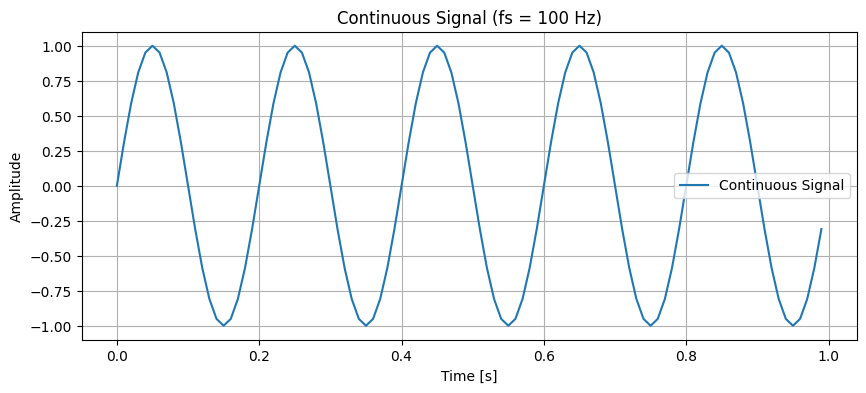

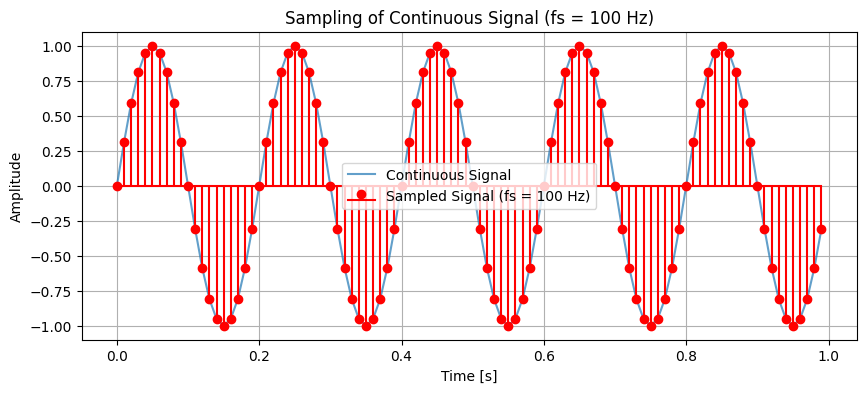

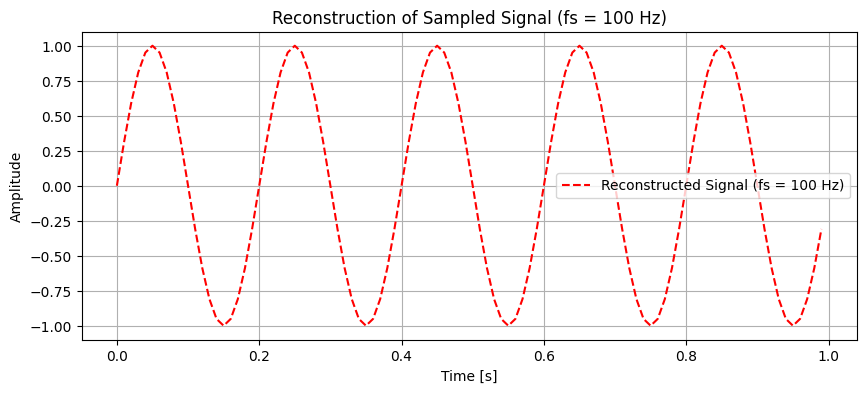

In [ ]:
# Impulse Sampling
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
fs = 100
t = np.arange(0, 1, 1/fs)
f = 5
signal = np.sin(2 * np.pi * f * t)
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Continuous Signal')
plt.title('Continuous Signal (fs = 100 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()
t_sampled = np.arange(0, 1, 1/fs)
signal_sampled = np.sin(2 * np.pi * f * t_sampled)
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Continuous Signal', alpha=0.7)
plt.stem(t_sampled, signal_sampled, linefmt='r-', markerfmt='ro',
basefmt='r-', label='Sampled Signal (fs = 100 Hz)')
plt.title('Sampling of Continuous Signal (fs = 100 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()
reconstructed_signal = resample(signal_sampled, len(t))
plt.figure(figsize=(10, 4))
# plt.plot(t, signal, label='Continuous Signal', alpha=0.7)
plt.plot(t, reconstructed_signal, 'r--', label='Reconstructed Signal (fs = 100 Hz)')
plt.title('Reconstruction of Sampled Signal (fs = 100 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()


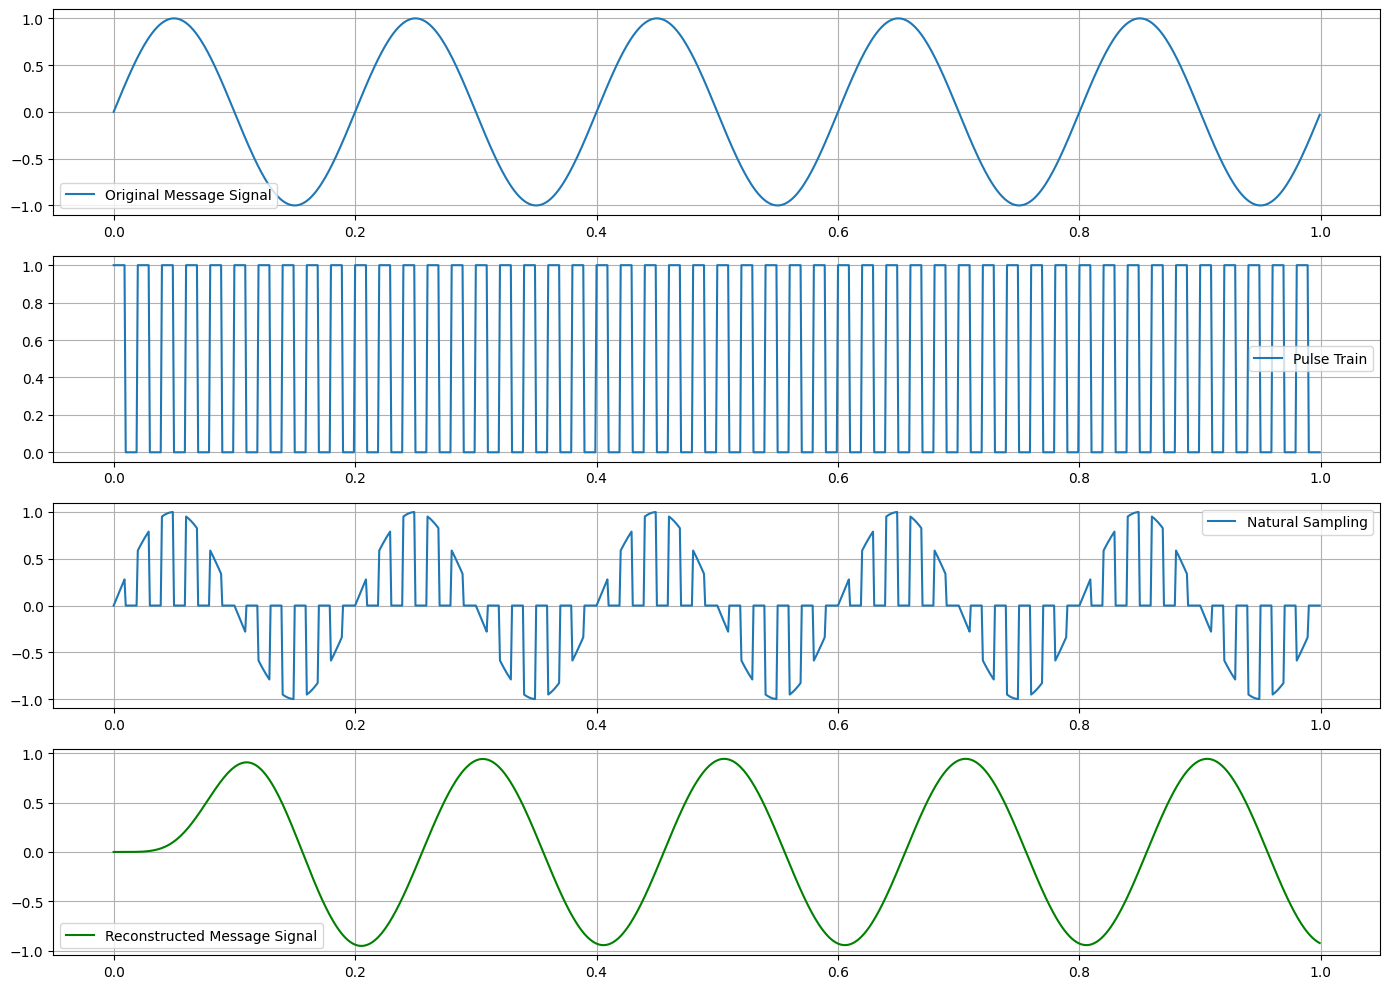

In [ ]:

# #Natural sampling
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
fs = 1000 # Sampling frequency (samples per second)
T = 1 # Duration in seconds
t = np.arange(0, T, 1/fs) # Time vector
fm = 5 # Frequency of message signal (Hz)
message_signal = np.sin(2 * np.pi * fm * t)
pulse_rate = 50 # pulses per second
pulse_train = np.zeros_like(t)
pulse_width = int(fs / pulse_rate / 2)
for i in range(0, len(t), int(fs / pulse_rate)):
    pulse_train[i:i+pulse_width] = 1
nat_signal = message_signal * pulse_train
sampled_signal = nat_signal[pulse_train == 1]
sample_times = t[pulse_train == 1]
# # Interpolation - Zero-Order Hold (just for visualization)
reconstructed_signal = np.zeros_like(t)
for i, time in enumerate(sample_times):
    index = np.argmin(np.abs(t - time))
    reconstructed_signal[index:index+pulse_width] = sampled_signal[i]
def lowpass_filter(signal, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, signal)
reconstructed_signal = lowpass_filter(reconstructed_signal,10, fs)
plt.figure(figsize=(14, 10))
plt.subplot(4, 1, 1)
plt.plot(t, message_signal, label='Original Message Signal')
plt.legend()
plt.grid(True)
plt.subplot(4, 1, 2)
plt.plot(t, pulse_train, label='Pulse Train')
plt.legend()
plt.grid(True)
plt.subplot(4, 1, 3)
plt.plot(t, nat_signal, label='Natural Sampling')
plt.legend()
plt.grid(True)
plt.subplot(4, 1, 4)
plt.plot(t, reconstructed_signal, label='Reconstructed Message Signal',
         color='green')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
